<a href="https://colab.research.google.com/github/pirjo2/Botbusters/blob/main/other_dataset_cleaned_bot_detection_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

# import pandas as pd
# df = pd.read_csv('bot_detection_data.csv')
# df['Bot Label'].value_counts()
# df.info()
# df.describe()
# df


In [1]:
# prompt: read in the gilani_2017.tsv and gilani-2017_tweets.json files
# # prompt: read in the gilani_2017.tsv and gilani-2017_tweets.json files
# import pandas as pd
# df_gilani = pd.read_csv('gilani_2017.tsv', sep='\t')
# df_tweets = pd.read_json('gilani-2017_tweets.json')
# first does not have a header. make headings id and label

import pandas as pd

df_tsv = pd.read_csv('gilani-2017.tsv', sep='\t', header=None, names=['id', 'label'])
df_json = pd.read_json('gilani-2017_tweets.json')

# print("Gilani DataFrame head:")
# print(df_gilani.head())

# print("\nTweets DataFrame head:")
# print(df_tweets.head())

In [2]:
# prompt: df_tsv.drop_duplicates(inplace=True)
# df_tsv
# drop duplicates and drop ids that have both labels

# Get IDs that have both labels
ids_with_both_labels = df_tsv.groupby('id')['label'].nunique()
ids_to_drop = ids_with_both_labels[ids_with_both_labels > 1].index

# Drop rows with the identified IDs
df_tsv_cleaned = df_tsv[~df_tsv['id'].isin(ids_to_drop)].copy()

df_tsv_cleaned.drop_duplicates(inplace=True)
df_tsv_cleaned


,id,label
0,461277906,bot
1,808280162,bot
2,1575510320,bot
3,2449235599,bot
4,1113769100,bot
...,...,...
2647,68765193,human
2648,782496626451546112,human
2649,134164413,human
2650,72378123,human


In [3]:
df_tsv.drop_duplicates(inplace=True)
df_tsv

,id,label
0,461277906,bot
1,808280162,bot
2,1575510320,bot
3,2449235599,bot
4,1113769100,bot
...,...,...
2647,68765193,human
2648,782496626451546112,human
2649,134164413,human
2650,72378123,human


In [4]:
df_json

,created_at,user
0,2019-01-21 19:37:21+00:00,"{'id': 613512037, 'id_str': '613512037', 'name..."
1,2019-01-21 20:42:18+00:00,"{'id': 19263978, 'id_str': '19263978', 'name':..."
2,2019-01-21 19:18:27+00:00,"{'id': 1624329463, 'id_str': '1624329463', 'na..."
3,2019-01-21 14:45:13+00:00,"{'id': 550610050, 'id_str': '550610050', 'name..."
4,2019-01-21 20:28:43+00:00,"{'id': 149714640, 'id_str': '149714640', 'name..."
...,...,...
2489,2017-06-05 23:53:56+00:00,"{'id': 3236431915, 'id_str': '3236431915', 'na..."
2490,2019-01-22 00:06:58+00:00,"{'id': 388843527, 'id_str': '388843527', 'name..."
2491,2019-01-18 16:45:06+00:00,"{'id': 2566083968, 'id_str': '2566083968', 'na..."
2492,2019-01-21 15:26:25+00:00,"{'id': 250121556, 'id_str': '250121556', 'name..."


In [5]:
import pandas as pd
import json

# Reload the df_json DataFrame from the original file
# The 'user' column will be automatically parsed into dictionaries by pd.read_json
df_json = pd.read_json('gilani-2017_tweets.json')

# The 'user' column already contains dictionaries, so we can directly convert it to a list of dictionaries
users_data = df_json['user'].tolist()
# Create a new DataFrame from the list of dictionaries
df_users = pd.DataFrame(users_data)
# Join the new DataFrame with the original DataFrame, dropping the original 'user' column
# df_json = df_json.drop('user', axis=1).join(df_users)

df_users#.columns

,id,id_str,name,screen_name,location,description,url,entities,protected,followers_count,...,profile_sidebar_fill_color,profile_text_color,profile_use_background_image,has_extended_profile,default_profile,default_profile_image,following,follow_request_sent,notifications,translator_type
0,613512037,613512037,Baseball Quotes,BaseballQuotes1,The Diamond,Quoting America's Pastime in 280 characters or...,None,{'description': {'urls': []}},False,121500,...,000000,000000,False,False,False,False,False,False,False,none
1,19263978,19263978,Cleveland Cavaliers,cavs,"The Q | Cleveland, OH",Official Twitter of the 2016 NBA Champion Clev...,https://t.co/XDJzEZarB0,{'url': {'urls': [{'url': 'https://t.co/XDJzEZ...,False,3227215,...,FDBC31,000000,True,False,False,False,False,False,False,none
2,1624329463,1624329463,‏المهاجر 1M,muohajer_12,المملكة العربية السعودية,,None,{'description': {'urls': []}},False,864968,...,DDEEF6,333333,True,False,True,False,False,False,False,none
3,550610050,550610050,BC.20,Bc20_,,R.I.P JRL21//R.I.P Monica💙 IG//b.20c #GLOHIOBOYS,None,{'description': {'urls': []}},False,951,...,DDEEF6,333333,False,True,False,False,False,False,False,none
4,149714640,149714640,mia 🧜🏾‍♀️🖤💋,_Blkahontas,"Hollywood, FL",to die for 🔮🤞🏾👸🏾,https://t.co/Y7Md3366Ky,{'url': {'urls': [{'url': 'https://t.co/Y7Md33...,False,1412,...,DDEEF6,241EBD,True,False,False,False,False,False,False,none
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2489,3236431915,3236431915,Adam McArthur,BigMacFlashy,"Phoenix, AZ",CEO of @thebambox and @comiconauction. Love De...,https://t.co/4MHS29rjze,{'url': {'urls': [{'url': 'https://t.co/4MHS29...,False,331,...,000000,000000,False,False,False,False,False,False,False,none
2490,388843527,388843527,Badrul,BadruulAminn,"Petaling, Selangor",20 / YouTuber + Streamer / Married /\n\nCome s...,https://t.co/2k86dljV8d,{'url': {'urls': [{'url': 'https://t.co/2k86dl...,False,71105,...,95E8EC,3C3940,True,True,False,False,False,False,False,regular
2491,2566083968,2566083968,Sav🌸,anxietyhes,,woke up the girl who looked just like you I al...,https://t.co/ZK3i8HNjoD,{'url': {'urls': [{'url': 'https://t.co/ZK3i8H...,False,99769,...,FFFFFF,000000,True,True,False,False,False,False,False,none
2492,250121556,250121556,遠@原付ベトナム縦断準備,EN_owl,なごやちほー,旧型クロスカブ改(プラウダ戦車色)に乗るガルパンおじさん。ノンナと愛里寿推し。日本一周201...,https://t.co/H4tJIPH6Dk,{'url': {'urls': [{'url': 'https://t.co/H4tJIP...,False,1222,...,000000,7A0A1D,True,False,False,False,False,False,False,none


In [6]:
# prompt: join df_tsv and df_users on id columns

df_merged = pd.merge(df_tsv, df_users, how = 'inner', on='id')
df_merged

,id,label,id_str,name,screen_name,location,description,url,entities,protected,...,profile_sidebar_fill_color,profile_text_color,profile_use_background_image,has_extended_profile,default_profile,default_profile_image,following,follow_request_sent,notifications,translator_type
0,461277906,bot,461277906,04 Limited Sazabys,04LS_nagoya,Nagoya/Japan,04 Limited Sazabysの公式Twitter。2008年名古屋で結成。ライブなど...,https://t.co/6z3deSPyKp,{'url': {'urls': [{'url': 'https://t.co/6z3deS...,False,...,000000,000000,False,False,False,False,False,False,False,none
1,808280162,bot,808280162,わんた,0gn,さいたまぁ,某炎上アカウント() #R6S PS4(初心者),None,{'description': {'urls': []}},False,...,DDEEF6,333333,True,True,True,False,False,False,False,none
2,1575510320,bot,1575510320,حومة فكر,0k__2,🇸🇦🇰🇼 مصير مشترك 🇸🇦🇰🇼,👍👍@9are_7👍👍,None,{'description': {'urls': []}},False,...,DDEEF6,333333,True,False,True,False,False,False,False,none
3,2449235599,bot,2449235599,ひしょーたん,0ts__,ミシシッピ川の端の方,,None,{'description': {'urls': []}},False,...,DDEEF6,333333,True,False,True,False,False,False,False,none
4,1113769100,bot,1113769100,♚ رحـــــــــالــــ♚,100rahal100,,‏‏‎‎‎‎‎‎ ‎‎‎@messfer20,https://t.co/0zcm8lFZNz,{'url': {'urls': [{'url': 'https://t.co/0zcm8l...,False,...,E3E2DE,634047,True,False,False,False,False,False,False,none
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2498,68765193,human,68765193,Gui Santana,oguisantana,São Paulo,Deus abençoa a quem sempre caçoa! VOCÊ NÃO ME ...,None,{'description': {'urls': [{'url': 'https://t.c...,False,...,9EA8AB,403D40,True,False,False,False,False,False,False,none
2499,782496626451546112,human,782496626451546112,Oğuz,ogzatbs,,:),None,{'description': {'urls': []}},False,...,DDEEF6,333333,True,False,True,False,False,False,False,none
2500,134164413,human,134164413,Relatable,omgrelatabIe,,Tweeting relatable thoughts & feelings. Just t...,None,{'description': {'urls': []}},False,...,FFFFFF,000000,False,True,False,False,False,False,False,regular
2501,72378123,human,72378123,Ömür Gedik,omurgedik,Turkey,"@hacikodernek, Boğaziçi Ü., Hürriyet, İletişim...",https://t.co/K1KPvq1xwR,{'url': {'urls': [{'url': 'https://t.co/K1KPvq...,False,...,DDEEF6,333333,True,False,True,False,False,False,False,none


In [7]:
# prompt: subsample df_merged so that it has same number of bot and humans in df_merged['label'].

# Assuming 'df_merged' is already created and has a 'label' column
# Find the minority class
minority_class = df_merged['label'].value_counts().idxmin()
minority_count = df_merged['label'].value_counts().min()

# Separate the majority and minority classes
df_majority = df_merged[df_merged['label'] != minority_class]
df_minority = df_merged[df_merged['label'] == minority_class]

# Undersample the majority class
df_majority_undersampled = df_majority.sample(n=minority_count, random_state=42) # random_state for reproducibility

# Concatenate the undersampled majority class with the minority class
df_sample = pd.concat([df_majority_undersampled, df_minority])

# Display the value counts of the subsampled DataFrame
print(df_sample['label'].value_counts())

# Now df_merged has the same number of bot and human samples

label
human    1090
bot      1090
Name: count, dtype: int64


In [8]:
df_merged['label'].value_counts()

label
human    1413
bot      1090
Name: count, dtype: int64

In [ ]:
# entities_data = df_merged['entities'].tolist()
# # Create a new DataFrame from the list of dictionaries
# df_entities = pd.DataFrame(entities_data)
# df_entities

In [9]:
df_merged.columns

Index(['id', 'label', 'id_str', 'name', 'screen_name', 'location',
       'description', 'url', 'entities', 'protected', 'followers_count',
       'friends_count', 'listed_count', 'created_at', 'favourites_count',
       'utc_offset', 'time_zone', 'geo_enabled', 'verified', 'statuses_count',
       'lang', 'contributors_enabled', 'is_translator',
       'is_translation_enabled', 'profile_background_color',
       'profile_background_image_url', 'profile_background_image_url_https',
       'profile_background_tile', 'profile_image_url',
       'profile_image_url_https', 'profile_banner_url', 'profile_link_color',
       'profile_sidebar_border_color', 'profile_sidebar_fill_color',
       'profile_text_color', 'profile_use_background_image',
       'has_extended_profile', 'default_profile', 'default_profile_image',
       'following', 'follow_request_sent', 'notifications', 'translator_type'],
      dtype='object')

In [ ]:
# {"name":"Username", "id": "User ID", "": "Tweet", "": "Retweet_Count", "Mention_Count", "Bot_Label", "Followers_count", "Verified", "Location", "Created At", "Hashtags"}

In [71]:
# NEW PART - Sample a manageable subset of users
# df_sample = df.sample(n=5000, random_state=42).reset_index(drop=True)

# Recompute the TF-IDF matrix on the sample
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(df_sample['description'])

In [72]:
df_sample['label'].value_counts()

label
human    1090
bot      1090
Name: count, dtype: int64

In [73]:

# NEW PART
from sklearn.metrics.pairwise import cosine_similarity
import networkx as nx

similarity_matrix = cosine_similarity(tfidf_matrix)
threshold = 0.2
G = nx.Graph()
for i in range(len(df_sample)):
    for j in range(i + 1, len(df_sample)):
        if similarity_matrix[i, j] > threshold:
            G.add_edge(i, j, weight=similarity_matrix[i, j])


In [13]:
!pip install node2vec

In [74]:
print(f"Graph has {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")

Graph has 955 nodes and 2115 edges


In [84]:
#
# NEW PART
from node2vec import Node2Vec
# dimensions': 128, 'num_walks': 200, 'p': 1, 'q': 1, 'walk_length': 30}
#  {'dimensions': 128, 'num_walks': 150, 'p': 2, 'q': 2, 'walk_length': 30}
# {'dimensions': 128, 'num_walks': 200, 'p': 0.5, 'q': 0.5, 'walk_length': 30}
node2vec = Node2Vec(G, dimensions=128, walk_length=30, num_walks=200, p=2, q=0.25, workers=2)
model = node2vec.fit(window=10, min_count=1)
embedding = [model.wv[str(i)] for i in range(len(df_sample)) if str(i) in model.wv]
labels = df_sample.loc[[str(i) in model.wv for i in range(len(df_sample))], 'label']

Computing transition probabilities:   0%|          | 0/955 [00:00<?, ?it/s]

In [85]:
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import numpy as np

X = np.array(embedding)
y = labels.to_numpy()

# Use cross_val_score to evaluate accuracy
clf = RandomForestClassifier()
scores = cross_val_score(clf, X, y, cv=5, scoring='accuracy')
print(f"5-fold accuracy: {np.mean(scores):.4f}")

# Get cross-validated predictions
y_pred = cross_val_predict(clf, X, y, cv=5)
print(classification_report(y, y_pred))

5-fold accuracy: 0.6262
              precision    recall  f1-score   support

         bot       0.61      0.64      0.63       480
       human       0.62      0.59      0.60       475

    accuracy                           0.62       955
   macro avg       0.62      0.62      0.62       955
weighted avg       0.62      0.62      0.62       955



<Axes: >

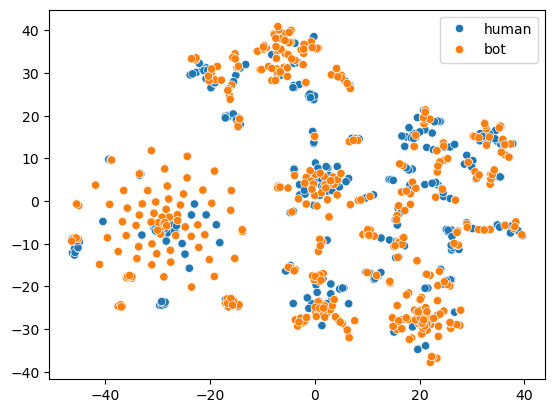

In [88]:
from sklearn.manifold import TSNE
import seaborn as sns

X_embedded = TSNE(n_components=2, random_state=42).fit_transform(X)
sns.scatterplot(x=X_embedded[:, 0], y=X_embedded[:, 1], hue=y)

In [87]:
from sklearn.model_selection import cross_val_score, cross_val_predict, ParameterGrid
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from node2vec import Node2Vec
import numpy as np

# Define parameter grid
param_grid = {
    'dimensions': [128],
    'walk_length': [30],
    'num_walks': [200, 300],
    'p': [0.5, 1, 2],
    'q': [0.5, 1, 2]
}

grid = ParameterGrid(param_grid)
best_score = 0
best_params = None

for params in grid:
    print(f"Trying params: {params}")
    try:
        node2vec = Node2Vec(
            G,
            dimensions=params['dimensions'],
            walk_length=params['walk_length'],
            num_walks=params['num_walks'],
            p=params['p'],
            q=params['q'],
            workers=2,
            seed=42,
            quiet=True
        )
        model = node2vec.fit(window=10, min_count=1)

        # Align embedding and labels
        embedding = [model.wv[str(i)] for i in range(len(df_sample)) if str(i) in model.wv]
        labels = df_sample.loc[[str(i) in model.wv for i in range(len(df_sample))], 'label']

        X = np.array(embedding)
        y = labels.to_numpy()

        clf = LogisticRegression(max_iter=1000)
        scores = cross_val_score(clf, X, y, cv=5, scoring='f1_macro')
        mean_score = np.mean(scores)

        print(f"F1 macro score: {mean_score:.4f}")

        if mean_score > best_score:
            best_score = mean_score
            best_params = params
    except Exception as e:
        print(f"Failed for params {params}: {e}")

print(f"\nBest F1 score: {best_score}")
print(f"Best parameters: {best_params}")

Trying params: {'dimensions': 128, 'num_walks': 200, 'p': 0.5, 'q': 0.5, 'walk_length': 30}
F1 macro score: 0.6195
Trying params: {'dimensions': 128, 'num_walks': 200, 'p': 0.5, 'q': 1, 'walk_length': 30}
F1 macro score: 0.5909
Trying params: {'dimensions': 128, 'num_walks': 200, 'p': 0.5, 'q': 2, 'walk_length': 30}
F1 macro score: 0.5809
Trying params: {'dimensions': 128, 'num_walks': 200, 'p': 1, 'q': 0.5, 'walk_length': 30}
F1 macro score: 0.6262
Trying params: {'dimensions': 128, 'num_walks': 200, 'p': 1, 'q': 1, 'walk_length': 30}
F1 macro score: 0.6082
Trying params: {'dimensions': 128, 'num_walks': 200, 'p': 1, 'q': 2, 'walk_length': 30}
F1 macro score: 0.5663
Trying params: {'dimensions': 128, 'num_walks': 200, 'p': 2, 'q': 0.5, 'walk_length': 30}
F1 macro score: 0.5830
Trying params: {'dimensions': 128, 'num_walks': 200, 'p': 2, 'q': 1, 'walk_length': 30}
F1 macro score: 0.6017
Trying params: {'dimensions': 128, 'num_walks': 200, 'p': 2, 'q': 2, 'walk_length': 30}
F1 macro sco

In [ ]:
# alates siit on jooksutatud terve andmestikuga, mitte df_sample, selle jaoks peab ülevalt muutma df_sample -> df_merged ja uuesti jooksutama

In [71]:
from sklearn.model_selection import cross_val_score, cross_val_predict, ParameterGrid
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from node2vec import Node2Vec
import numpy as np

# Define parameter grid
param_grid = {
    'dimensions': [128],
    'walk_length': [30],
    'num_walks': [200, 300],
    'p': [0.5, 1, 2],
    'q': [0.5, 1, 2]
}

grid = ParameterGrid(param_grid)
best_score = 0
best_params = None

for params in grid:
    print(f"Trying params: {params}")
    try:
        node2vec = Node2Vec(
            G,
            dimensions=params['dimensions'],
            walk_length=params['walk_length'],
            num_walks=params['num_walks'],
            p=params['p'],
            q=params['q'],
            workers=2,
            seed=42,
            quiet=True
        )
        model = node2vec.fit(window=10, min_count=1)

        # Align embedding and labels
        embedding = [model.wv[str(i)] for i in range(len(df_sample)) if str(i) in model.wv]
        labels = df_sample.loc[[str(i) in model.wv for i in range(len(df_sample))], 'label']

        X = np.array(embedding)
        y = labels.to_numpy()

        clf = LogisticRegression(max_iter=1000)
        scores = cross_val_score(clf, X, y, cv=5, scoring='f1_macro')
        mean_score = np.mean(scores)

        print(f"F1 macro score: {mean_score:.4f}")

        if mean_score > best_score:
            best_score = mean_score
            best_params = params
    except Exception as e:
        print(f"Failed for params {params}: {e}")

print(f"\nBest F1 score: {best_score}")
print(f"Best parameters: {best_params}")

Trying params: {'dimensions': 128, 'num_walks': 200, 'p': 0.5, 'q': 0.5, 'walk_length': 30}
F1 macro score: 0.6381
Trying params: {'dimensions': 128, 'num_walks': 200, 'p': 0.5, 'q': 1, 'walk_length': 30}
F1 macro score: 0.6158
Trying params: {'dimensions': 128, 'num_walks': 200, 'p': 0.5, 'q': 2, 'walk_length': 30}
F1 macro score: 0.6240
Trying params: {'dimensions': 128, 'num_walks': 200, 'p': 1, 'q': 0.5, 'walk_length': 30}
F1 macro score: 0.6072
Trying params: {'dimensions': 128, 'num_walks': 200, 'p': 1, 'q': 1, 'walk_length': 30}
F1 macro score: 0.6283
Trying params: {'dimensions': 128, 'num_walks': 200, 'p': 1, 'q': 2, 'walk_length': 30}
F1 macro score: 0.5986
Trying params: {'dimensions': 128, 'num_walks': 200, 'p': 2, 'q': 0.5, 'walk_length': 30}
F1 macro score: 0.6183
Trying params: {'dimensions': 128, 'num_walks': 200, 'p': 2, 'q': 1, 'walk_length': 30}
F1 macro score: 0.6095
Trying params: {'dimensions': 128, 'num_walks': 200, 'p': 2, 'q': 2, 'walk_length': 30}
F1 macro sco

In [72]:
print("Best F1 score:", best_score)
print("Best parameters:", best_params)

Best F1 score: 0.6380510617535355
Best parameters: {'dimensions': 128, 'num_walks': 200, 'p': 0.5, 'q': 0.5, 'walk_length': 30}


In [83]:
from sklearn.model_selection import cross_val_score, cross_val_predict, ParameterGrid
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from node2vec import Node2Vec
import numpy as np

# Define parameter grid
param_grid = {
    'dimensions': [64, 128],
    'walk_length': [30],
    'num_walks': [200],
    'p': [0.25, 0.5],
    'q': [0.25, 0.5]
}

grid = ParameterGrid(param_grid)
best_score = 0
best_params = None

for params in grid:
    print(f"Trying params: {params}")
    try:
        node2vec = Node2Vec(
            G,
            dimensions=params['dimensions'],
            walk_length=params['walk_length'],
            num_walks=params['num_walks'],
            p=params['p'],
            q=params['q'],
            workers=2,
            seed=42,
            quiet=True
        )
        model = node2vec.fit(window=10, min_count=1)

        # Align embedding and labels
        embedding = [model.wv[str(i)] for i in range(len(df_sample)) if str(i) in model.wv]
        labels = df_sample.loc[[str(i) in model.wv for i in range(len(df_sample))], 'label']

        X = np.array(embedding)
        y = labels.to_numpy()

        clf = LogisticRegression(max_iter=1000)
        scores = cross_val_score(clf, X, y, cv=5, scoring='f1_macro')
        mean_score = np.mean(scores)

        print(f"F1 macro score: {mean_score:.4f}")

        if mean_score > best_score:
            best_score = mean_score
            best_params = params
    except Exception as e:
        print(f"Failed for params {params}: {e}")

print(f"\nBest F1 score: {best_score}")
print(f"Best parameters: {best_params}")

Trying params: {'dimensions': 64, 'num_walks': 200, 'p': 0.25, 'q': 0.25, 'walk_length': 30}
F1 macro score: 0.6251
Trying params: {'dimensions': 64, 'num_walks': 200, 'p': 0.25, 'q': 0.5, 'walk_length': 30}
F1 macro score: 0.6256
Trying params: {'dimensions': 64, 'num_walks': 200, 'p': 0.5, 'q': 0.25, 'walk_length': 30}
F1 macro score: 0.6214
Trying params: {'dimensions': 64, 'num_walks': 200, 'p': 0.5, 'q': 0.5, 'walk_length': 30}
F1 macro score: 0.6100
Trying params: {'dimensions': 128, 'num_walks': 200, 'p': 0.25, 'q': 0.25, 'walk_length': 30}
F1 macro score: 0.6146
Trying params: {'dimensions': 128, 'num_walks': 200, 'p': 0.25, 'q': 0.5, 'walk_length': 30}
F1 macro score: 0.6045
Trying params: {'dimensions': 128, 'num_walks': 200, 'p': 0.5, 'q': 0.25, 'walk_length': 30}
F1 macro score: 0.6139
Trying params: {'dimensions': 128, 'num_walks': 200, 'p': 0.5, 'q': 0.5, 'walk_length': 30}
F1 macro score: 0.6101

Best F1 score: 0.6256106111906531
Best parameters: {'dimensions': 64, 'num_

In [66]:
#
# NEW PART
from node2vec import Node2Vec
# dimensions': 128, 'num_walks': 200, 'p': 1, 'q': 1, 'walk_length': 30}
#  {'dimensions': 128, 'num_walks': 150, 'p': 2, 'q': 2, 'walk_length': 30}
# {'dimensions': 128, 'num_walks': 200, 'p': 0.5, 'q': 0.5, 'walk_length': 30}
# {'dimensions': 64, 'num_walks': 200, 'p': 0.25, 'q': 0.5, 'walk_length': 30}
# 128	200	30	2	0.25
node2vec = Node2Vec(G, dimensions=128, walk_length=30, num_walks=200, p=2, q=0.25, workers=2)
model = node2vec.fit(window=10, min_count=1)
embedding = [model.wv[str(i)] for i in range(len(df_merged)) if str(i) in model.wv]
labels = df_merged.loc[[str(i) in model.wv for i in range(len(df_merged))], 'label']

Computing transition probabilities:   0%|          | 0/1119 [00:00<?, ?it/s]

In [68]:
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import numpy as np

X = np.array(embedding)
y = labels.to_numpy()

# Use cross_val_score to evaluate accuracy
clf = RandomForestClassifier()
scores = cross_val_score(clf, X, y, cv=5, scoring='accuracy')
print(f"5-fold accuracy: {np.mean(scores):.4f}")

# Get cross-validated predictions
y_pred = cross_val_predict(clf, X, y, cv=5)
print(classification_report(y, y_pred))

5-fold accuracy: 0.6327
              precision    recall  f1-score   support

         bot       0.56      0.49      0.53       490
       human       0.64      0.70      0.67       629

    accuracy                           0.61      1119
   macro avg       0.60      0.60      0.60      1119
weighted avg       0.61      0.61      0.61      1119



In [161]:
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import numpy as np

X = np.array(embedding)
y = labels.to_numpy()

# Use cross_val_score to evaluate accuracy
clf = RandomForestClassifier()
scores = cross_val_score(clf, X, y, cv=5, scoring='accuracy')
print(f"5-fold accuracy: {np.mean(scores):.4f}")

# Get cross-validated predictions
y_pred = cross_val_predict(clf, X, y, cv=5)
print(classification_report(y, y_pred))

5-fold accuracy: 0.6380
              precision    recall  f1-score   support

         bot       0.56      0.51      0.53       490
       human       0.64      0.70      0.67       629

    accuracy                           0.61      1119
   macro avg       0.60      0.60      0.60      1119
weighted avg       0.61      0.61      0.61      1119



<Axes: >

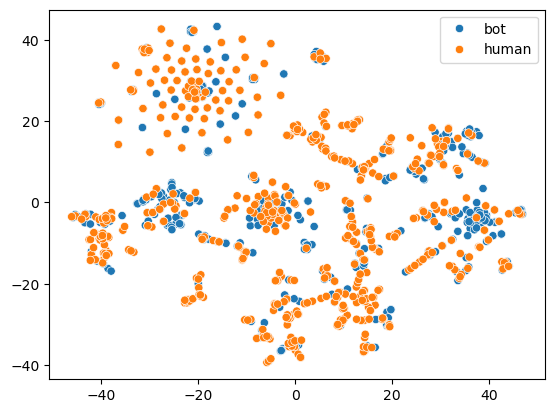

In [70]:
from sklearn.manifold import TSNE
import seaborn as sns

X_embedded = TSNE(n_components=2, random_state=42).fit_transform(X)
sns.scatterplot(x=X_embedded[:, 0], y=X_embedded[:, 1], hue=y)